# Log in

In [ ]:
import qnexus as qnx
qnx.login()

In [2]:
project_name = "EulerCartanEncoder_prod_h2-1"
project = qnx.projects.get_or_create(name=project_name)
qnx.context.set_active_project(project)

# Circuit creation

In [3]:
from anszats import EulerCartanEncoder
import numpy as np
import qnexus as qnx
from pathlib import Path

In [ ]:
ropes_f=Path('ropes_v2.npy')
encoder=EulerCartanEncoder
encoder_scale= 1 
n_q = 56

ropes = np.load(ropes_f, allow_pickle=True)
encoder_obj = encoder(n=2**int(np.log2(ropes.shape[-1])), q=n_q, scale=encoder_scale)

In [ ]:
indices = range(len(ropes))
circuits = []

for i in indices:
    params = ropes[i, :, :]
    circ0 = encoder_obj.dispatch(params[0, :])
    circ1 = encoder_obj.dispatch(params[1, :])
    circuit = circ0 >> circ1.dagger()
    circuit.measure_all()
    circuits.append(circuit)

print(f'Created {len(circuits)} circuits.')

Created 16 circuits.


In [21]:
from pytket.circuit.display import render_circuit_jupyter as draw
# draw(circuits[0])

# Upload to nexus

In [8]:
circuit_refs = []

for i, circ in enumerate(circuits):
    circuit_ref = qnx.circuits.upload(
        circ, 
        name=f"h2-prod-eulercartencoder-circ{i}-{n_q}q"
    )
    circuit_refs.append(circuit_ref)

In [ ]:
circuit_refs

# Download from nexus (if needed)

In [14]:
circuit_refs = []

for i, circ in enumerate(circuits):
    circuit_ref = qnx.circuits.get(
        # circ, 
        name=f"h2-prod-eulercartencoder-circ{i}-{n_q}q"
    )
    circuit_refs.append(circuit_ref)

In [ ]:
circuit_refs

# Compilation

In [10]:
# START COMPILE JOB
from quantinuum_schemas.models.backend_config import QuantinuumCompilerOptions

# system_name="H2-1"  # Emulator
system_name="H2-1"    # Real

circs_to_compile = circuit_refs
compiler_options = QuantinuumCompilerOptions(**{
    "target_2qb_gate": 'TK2',
})

config = qnx.QuantinuumConfig(device_name=system_name, compiler_options=compiler_options)

ref_compile_job = qnx.start_compile_job(
    programs=circs_to_compile,
    backend_config=config,
    optimisation_level=1,
    name=f"compilation-job-{system_name}_{len(circs_to_compile)}circs_{n_q}q",
)

In [11]:
qnx.jobs.wait_for(ref_compile_job)

JobStatus(status=<JobStatusEnum.COMPLETED: 'COMPLETED'>, message='The job is completed.', error_detail=None, completed_time=datetime.datetime(2026, 2, 9, 11, 9, 3, 745789, tzinfo=datetime.timezone.utc), queued_time=datetime.datetime(2026, 2, 9, 11, 8, 42, 506256, tzinfo=datetime.timezone.utc), submitted_time=datetime.datetime(2026, 2, 9, 11, 8, 32, 705178, tzinfo=datetime.timezone.utc), running_time=datetime.datetime(2026, 2, 9, 11, 8, 42, 704198, tzinfo=datetime.timezone.utc), cancelled_time=None, error_time=None, queue_position=None, cost=None)

In [ ]:
# GET PREVIOUS JOB IF NEEDED

# ref_compile_job = qnx.client.jobs.get(id="27a49987-2a3d-4b37-bc30-99ff07139f24")

In [5]:
compiled_circuits = [item.get_output() for item in qnx.jobs.results(ref_compile_job)]

In [ ]:
compiled_circuits

In [11]:
from pytket.circuit.display import render_circuit_jupyter as draw
# draw(circuits[0])

# Execution

In [14]:
# Estimate cost

config_tk2 = qnx.QuantinuumConfig(device_name="H2-1", target_2qb_gate="TK2")

n_shots_1_sim = 100

costs = []

for comp_circ in compiled_circuits[0:1]:
    cost = qnx.client.circuits.cost(
        circuit_ref=comp_circ, 
        n_shots=n_shots_1_sim, 
        backend_config=config_tk2,
        syntax_checker="H2-1SC",
    )
    costs.append(cost)

sum(costs), costs

(49.96, [49.96])

In [7]:
system_name="H2-1"  # Real
config_tk2 = qnx.QuantinuumConfig(device_name="H2-1", target_2qb_gate="TK2")

In [12]:
# START EXECUTION JOB

job_repreat = 4 # Since we're going to make ~8 repeats - this helps to manage job naming

n_shots_1_sim = 100

execute_job_ref = qnx.start_execute_job(
    programs=compiled_circuits,
    name=f"{system_name}-{n_q}q-eulercartencoder-prod-{job_repreat}",
    n_shots=[n_shots_1_sim] * len(compiled_circuits),
    backend_config=config_tk2,
)

In [ ]:
# WAIT FOR IT TO FINISH

qnx.jobs.wait_for(execute_job_ref)

# Loading results (single job)

In [ ]:
# GET PREVIOUS JOB IF NEEDED

# execute_job_ref = qnx.client.jobs.get(id="ffce57ad-24fa-4193-9fd6-a40d8710570b") # job 1
# execute_job_ref = qnx.client.jobs.get(id="1ac8afe0-3a86-4a34-8b73-e4a4fd49943a") # job 2
# execute_job_ref = qnx.client.jobs.get(id="a212e799-b6ba-457f-a744-24677727ecbe") # job 3
execute_job_ref = qnx.client.jobs.get(id="10028f03-76c3-4386-ba39-46d66e9d7cae") # job 4

job_results = qnx.jobs.results(execute_job_ref)

# assert len(job_results) == len(refs_hugr)

counts_all_zero = [0]*len(job_results)
n_q= 56 

for i in range(len(job_results)):
    result = job_results[i].download_result()
    counts_all_zero[i] = result.get_counts().get(tuple([0]*n_q),0)/100

In [23]:
counts_all_zero

[0.65,
 0.72,
 0.65,
 0.53,
 0.42,
 0.46,
 0.39,
 0.37,
 0.34,
 0.26,
 0.25,
 0.21,
 0.1,
 0.19,
 0.11,
 0.11]

# Plotting

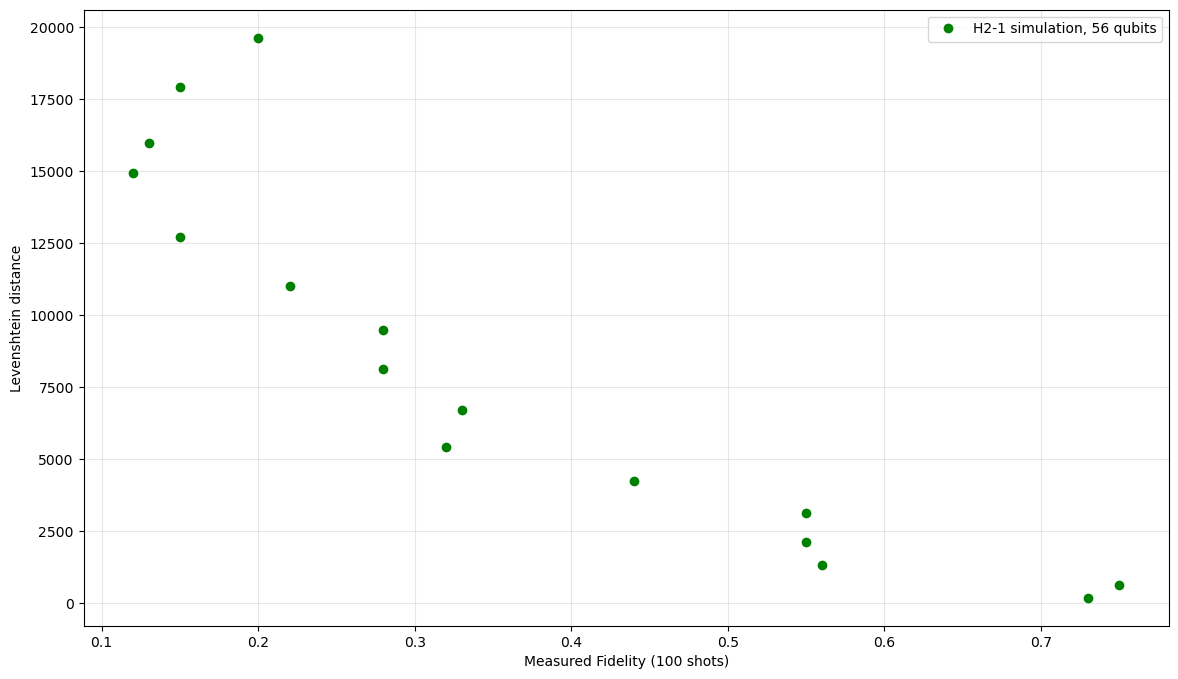

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

system_name="H2-1" 

n_shots_1_sim = 100

y = np.load('points_v2.npy')

levenshtein_distance_dim = 0 # my guess

y = y[:, levenshtein_distance_dim]

# ----------------------------------------
#  PLOT
# ----------------------------------------
plt.figure(figsize=(14,8))

plt.errorbar(counts_all_zero, y, fmt='o', color='green',
             label=f"{system_name} simulation, {n_q} qubits")

plt.xlabel(f"Measured Fidelity ({n_shots_1_sim} shots)")
plt.ylabel("Levenshtein distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plotting (multiple repreats)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

system_name="H2-2E" #"H2-2" #For real H2

n_shots_1_sim = 100

y = np.load('points_v2.npy')

levenshtein_distance_dim = 0 # my guess

y = y[:, levenshtein_distance_dim]

sim_runs = np.array(list(jobs_results.values()))

sim_mean = sim_runs.mean(axis=0)
sim_sd   = sim_runs.std(axis=0)
sim_var  = sim_runs.var(axis=0)

# ----------------------------------------
#  PLOT
# ----------------------------------------
plt.figure(figsize=(14,8))

plt.errorbar(sim_mean, y, xerr=sim_sd, fmt='o', color='green',
             label=f"{system_name} simulation, {n_q} qubits (mean ± SD)", capsize=4)

plt.xlabel(f"Measured Fidelity ({int(n_shots_1_sim * len(jobs_results))} shots)")
plt.ylabel("Levenshtein distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()